# Анализ ранее сохранённых результатов
§6.1.6, стр. 204–207. Моделирование здесь не повторяется.

In [1]:
using DrWatson
@quickactivate "project"
include(srcdir("SIRPetri.jl"))
using .SIRPetri
include(srcdir("experiment_support.jl"))

animate_sir

## Независимое чтение трёх обязательных CSV

In [2]:
df_det = CSV.read(datadir("sir_det.csv"), DataFrame)
df_stoch = CSV.read(datadir("sir_stoch.csv"), DataFrame)
df_scan = CSV.read(datadir("sir_scan.csv"), DataFrame)
(nrow(df_det), nrow(df_stoch), nrow(df_scan))

(201, 1992, 15)

## Сравнение I(t) по действительным временам

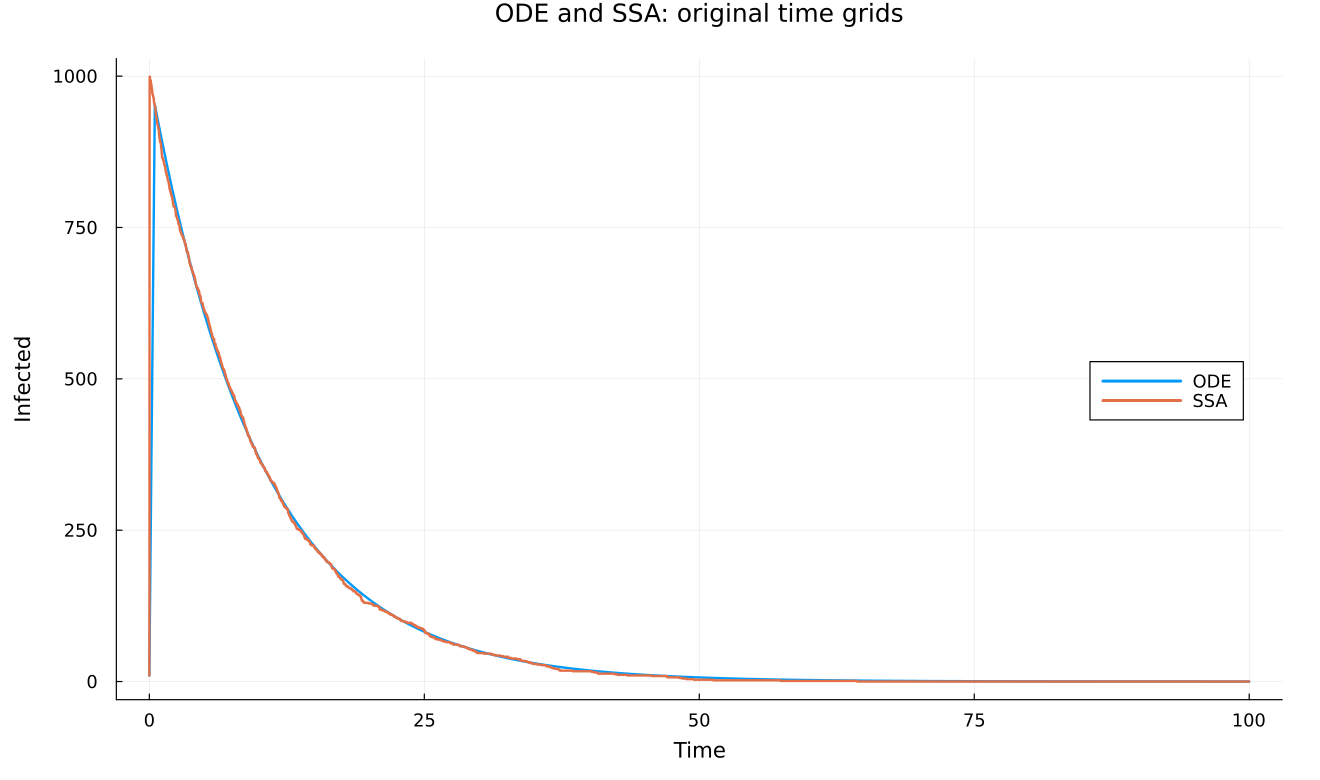

In [3]:
p_comparison = plot(df_det.time, df_det.I; label="ODE", xlabel="Time",
    ylabel="Infected", title="ODE and SSA: original time grids")
plot!(p_comparison, df_stoch.time, df_stoch.I; label="SSA", seriestype=:steppost)
savefig(p_comparison, imagepath("08-plot.png"))
display(p_comparison)

## Численная разность на общей сетке

In [4]:
aligned = state_at(df_stoch, df_det.time)
difference = DataFrame(time=df_det.time, ODE_I=df_det.I, SSA_I=aligned.I,
    difference=aligned.I .- df_det.I)
save_table("sir_comparison.csv", difference)
metrics = DataFrame(rmse_I=[sqrt(mean(difference.difference.^2))],
    max_abs_I=[maximum(abs.(difference.difference))])
save_table("sir_comparison_summary.csv", metrics)
metrics

Row,rmse_I,max_abs_I
,Float64,Float64
1,3.59544,19.0308


## Чувствительность без повторного расчёта

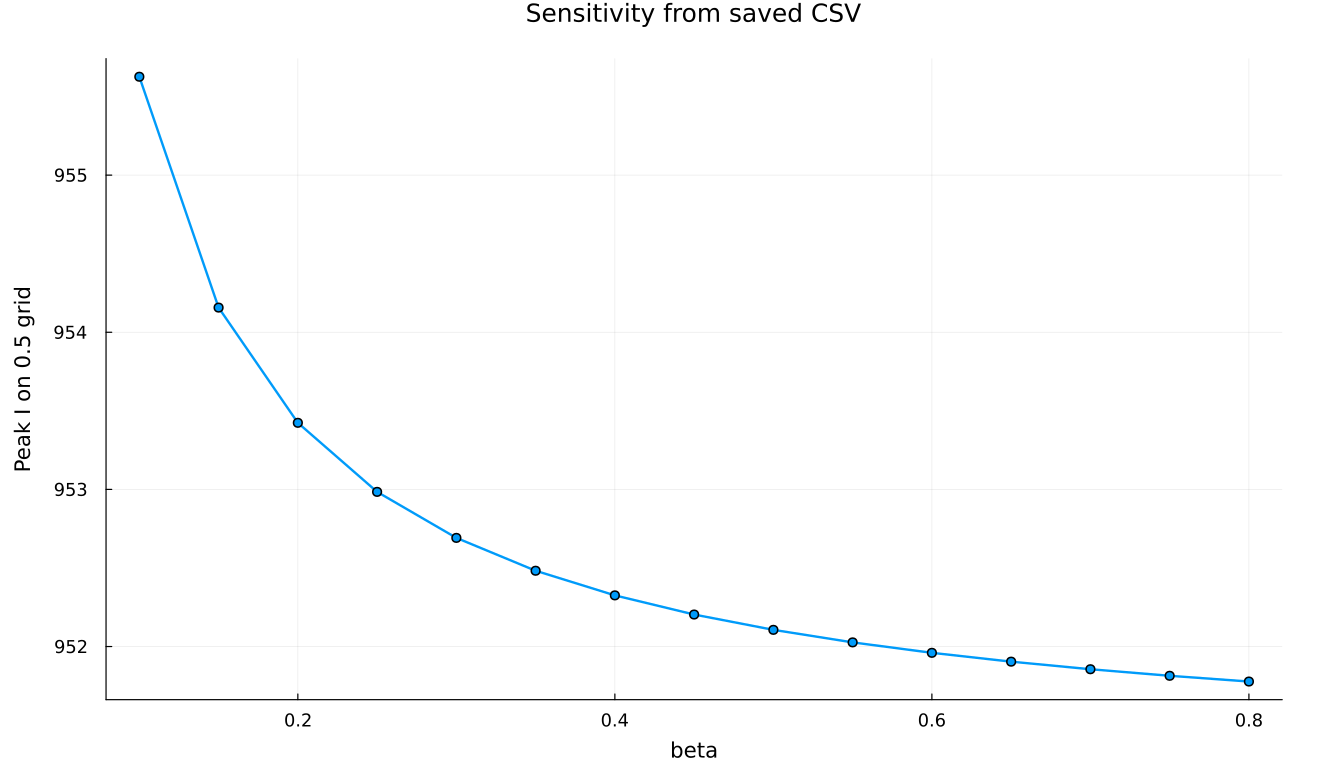

In [5]:
p_sensitivity = plot(df_scan.β, df_scan.peak_I; marker=:circle, label=false,
    xlabel="beta", ylabel="Peak I on 0.5 grid", title="Sensitivity from saved CSV")
savefig(p_sensitivity, imagepath("09-plot.png"))
display(p_sensitivity)